In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [58]:
df= pd.read_csv('healthcare-dataset-stroke-data.csv')

In [59]:
df.head(3)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1


In [60]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [61]:
df = df.drop(['id','work_type', 'Residence_type',], axis=1)

In [62]:
df.head(3)

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,105.92,32.5,never smoked,1


In [63]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
avg_glucose_level,0
bmi,201
smoking_status,0
stroke,0


In [64]:
df['bmi']= df['bmi'].fillna(df['bmi'].mean())

In [65]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
avg_glucose_level,0
bmi,0
smoking_status,0
stroke,0


In [66]:
df.head(3)

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,105.92,32.500000,never smoked,1


In [67]:
df = df.rename(columns={'avg_glucose_level': 'GlucoseLevel'})

# Standardization

In [68]:
df['stroke'] = df['stroke'].map({1: 'Yes', 0: 'No'})

In [69]:
df.head(2)

,gender,age,hypertension,heart_disease,ever_married,GlucoseLevel,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,228.69,36.600000,formerly smoked,Yes
1,Female,61.0,0,0,Yes,202.21,28.893237,never smoked,Yes


In [70]:
df['stroke'] = df['stroke'].map({'Yes': 1, 'No': 0})

In [71]:
df.head(2)

,gender,age,hypertension,heart_disease,ever_married,GlucoseLevel,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,202.21,28.893237,never smoked,1


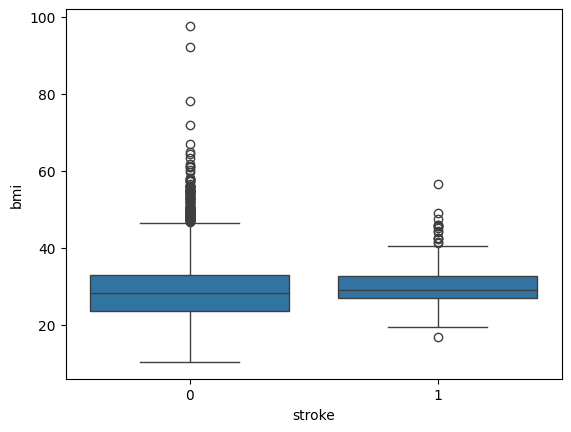

In [72]:
sn.boxplot(x='stroke', y='bmi',data=df)
plt.show()

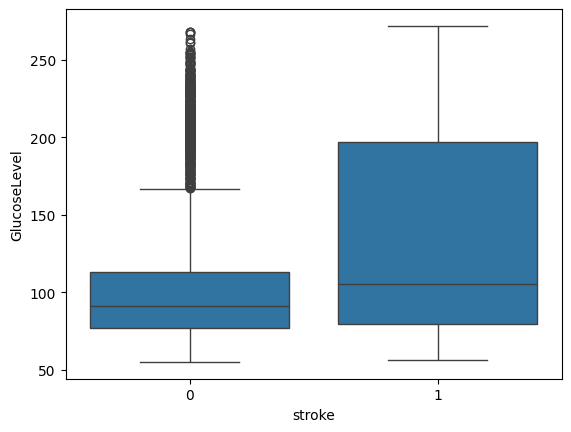

In [73]:
sn.boxplot(x='stroke', y='GlucoseLevel',data=df)
plt.show()

In [74]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'GlucoseLevel', 'bmi', 'smoking_status', 'stroke'],
      dtype='object')

In [75]:
df.head(2)

,gender,age,hypertension,heart_disease,ever_married,GlucoseLevel,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,202.21,28.893237,never smoked,1


In [76]:
df1=df[['bmi', 'GlucoseLevel']]

In [77]:
df1

,bmi,GlucoseLevel
0,36.600000,228.69
1,28.893237,202.21
2,32.500000,105.92
3,34.400000,171.23
4,24.000000,174.12
...,...,...
5105,28.893237,83.75
5106,40.000000,125.20
5107,30.600000,82.99
5108,25.600000,166.29


In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [79]:
scaler.fit(df1)

StandardScaler()

In [80]:
scaled_features = scaler.transform(df1)

In [81]:
scaled_features

array([[ 1.00123401e+00,  2.70637544e+00],
       [ 4.61555355e-16,  2.12155854e+00],
       [ 4.68577254e-01, -5.02830130e-03],
       ...,
       [ 2.21736316e-01, -5.11442636e-01],
       [-4.27845098e-01,  1.32825706e+00],
       [-3.49895329e-01, -4.60867458e-01]])

In [82]:
df2 = pd.DataFrame(scaled_features,columns=df1.columns)
df2.head()

,bmi,GlucoseLevel
0,1.001234e+00,2.706375
1,4.615554e-16,2.121559
2,4.685773e-01,-0.005028
3,7.154182e-01,1.437358
4,-6.357112e-01,1.501184


In [83]:
df2['stroke'] = df['stroke']

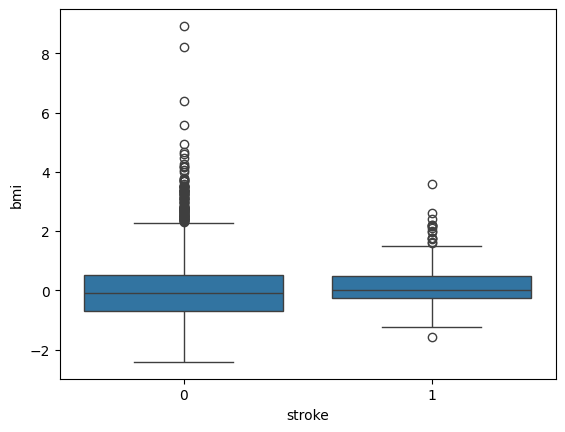

In [84]:
sn.boxplot(x='stroke', y='bmi',data=df2)
plt.show()

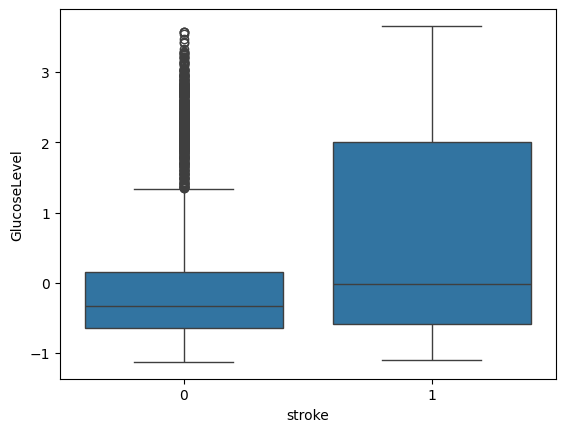

In [85]:
sn.boxplot(x='stroke', y='GlucoseLevel',data=df2)
plt.show()

Min Max

In [86]:
df1=df[['bmi', 'GlucoseLevel']]

In [87]:
df1

,bmi,GlucoseLevel
0,36.600000,228.69
1,28.893237,202.21
2,32.500000,105.92
3,34.400000,171.23
4,24.000000,174.12
...,...,...
5105,28.893237,83.75
5106,40.000000,125.20
5107,30.600000,82.99
5108,25.600000,166.29


In [88]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Correct: list of column names
cols_to_scale = ['bmi', 'GlucoseLevel']

# Initialize scaler
scaler = MinMaxScaler()

# Apply scaler and assign back
df1[cols_to_scale] = scaler.fit_transform(df1[cols_to_scale])

# Print result
print(df1.head())


        bmi  GlucoseLevel
0  0.301260      0.801265
1  0.212981      0.679023
2  0.254296      0.234512
3  0.276060      0.536008
4  0.156930      0.549349


<ipython-input-88-2870470792>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[cols_to_scale] = scaler.fit_transform(df1[cols_to_scale])


In [89]:
df1['stroke'] = df['stroke']

<ipython-input-89-633025355>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['stroke'] = df['stroke']


In [90]:
df1.head()

,bmi,GlucoseLevel,stroke
0,0.301260,0.801265,1
1,0.212981,0.679023,1
2,0.254296,0.234512,1
3,0.276060,0.536008,1
4,0.156930,0.549349,1


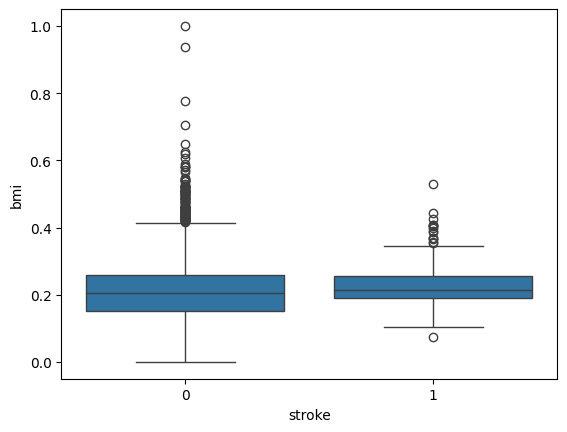

In [91]:
sn.boxplot(x='stroke', y='bmi',data=df1)
plt.show()

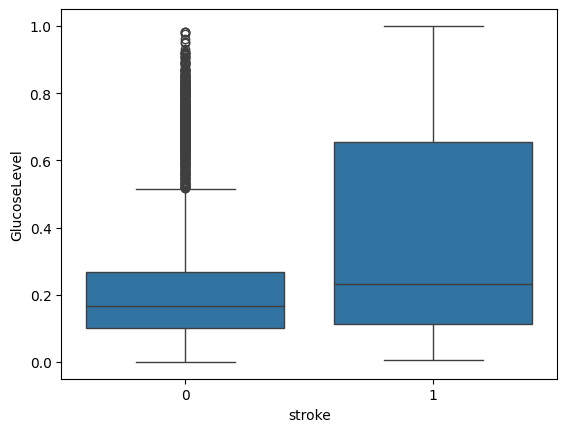

In [92]:
sn.boxplot(x='stroke', y='GlucoseLevel',data=df1)
plt.show()